In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.stats as st

matplotlib.rcParams['pdf.fonttype'] = 42


In [2]:
genotyping_mode = 'gapfill'
betaine_condition = 'betaine'

adata = sc.read_h5ad('../output/' + genotyping_mode + '_' + betaine_condition + '_mega_genotyped_adata.h5ad')

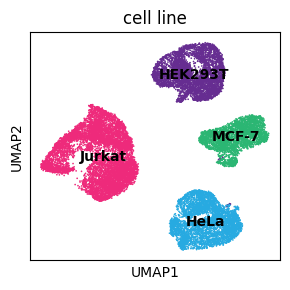

In [3]:
fig,ax = plt.subplots(figsize=(3,3))
sc.pl.umap(adata, color='cell_type', palette={'HeLa':'#27aae1','Jurkat':'#ee2a7b','HEK293T':'#662d91','MCF-7':'#2bb673'},ax=ax, title='cell line',show=False, legend_loc='on data')
plt.tight_layout()
plt.savefig('../plots/CL_mega_UMAP_cell_types.pdf', bbox_inches='tight')

Correlation between n_genes_by_counts and n targets genotyped: SignificanceResult(statistic=0.7192773296563931, pvalue=0.0)


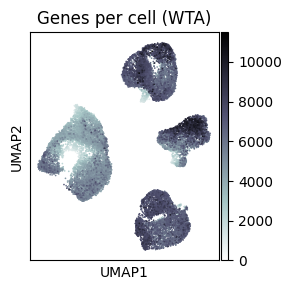

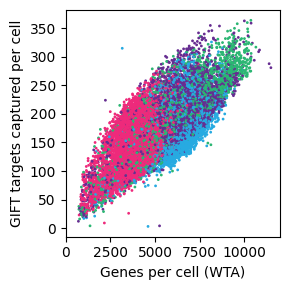

In [4]:
fig,ax = plt.subplots(figsize=(3,3))
adata.obs['log10_n_genes_by_counts'] = np.log10(adata.obs['n_genes_by_counts'])
sc.pl.umap(adata, color='n_genes_by_counts', cmap='bone_r', ax=ax, show=False, vmin = 0, title = 'Genes per cell (WTA)')
plt.tight_layout()
plt.savefig('../plots/CL_mega_UMAP_WTA_genes_per_cell.pdf', bbox_inches='tight')

adata.obs['n_targets_genotyped'] = adata.obsm['genotypes'].notna().sum(axis=1)
x = adata.obs['n_genes_by_counts']
y = adata.obs['n_targets_genotyped']
print(f"Correlation between n_genes_by_counts and n targets genotyped: {st.spearmanr(x, y)}")

fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(x, y, s=1, color = adata.obs['cell_type'].map({'HeLa':'#27aae1','Jurkat':'#ee2a7b','HEK293T':'#662d91','MCF-7':'#2bb673'}), alpha=1)
ax.set_xlim(0, 12000)
ax.set_xlabel('Genes per cell (WTA)')
ax.set_ylabel('GIFT targets captured per cell')
plt.tight_layout()

plt.savefig('../plots/CL_mega_UMAP_targets_genotyped_vs_wta_counts.pdf', bbox_inches='tight')


In [5]:
adata.obs['n_targets_genotyped'].fillna(0).median()

164.0